# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## Notebook P3-06: UBFC-rPPG Phase-3 Preprocessing

### What this notebook does
Maps the UBFC-rPPG dataset (DATASET_2, 42 subjects) into the unified Phase-3 schema: one consolidated HDF5 with one group per recording. Frames are decoded from each subject's vid.avi and face-cropped to 72x72; the BVP label is the contact PPG from ground_truth.txt, interpolated onto the video frame times.

### Role in Phase 3
UBFC-rPPG is a clean resting TRAINING set (42 subjects, one ~1 min video each). It feeds the HR head via the BVP waveform. It has no ECG, no biomarkers and no respiration, so those fields are absent/masked. Together with MCD-rPPG and DLCN it completes the committed training corpus (~2,000 recordings).

### Why the BVP needs interpolation
UBFC ground_truth.txt has three rows (PPG, HR, timestamps) sampled at the pulse-oximeter's own irregular rate, shorter than and not frame-aligned to the video. So the PPG and HR are interpolated onto uniform video frame times to produce a frame-synced label, rather than used directly.

### Pipeline
subjectN/ -> for each subject:
  decode vid.avi -> MediaPipe face box (stable, from sampled frames) -> crop + resize to 72
  ground_truth.txt (row0 PPG, row1 HR, row2 timestamps) -> interpolate onto frame times = frame-synced bvp + hr
  -> write one group per recording into the consolidated UBFC-rPPG Phase-3 HDF5 



### Unified Phase-3 schema (v1) — UBFC-rPPG specifics
Same grouped 72x72 layout as the other Phase-3 datasets. For UBFC-rPPG each recording group holds:

| name | source | present | notes |
|------|--------|---------|-------|
| frames | face-cropped vid.avi | yes | [T, 72, 72, 3] uint8 |
| bvp | ground_truth PPG (interp to frames) | yes | frame-synced HR label |
| hr | ground_truth HR (interp to frames) | yes | per-frame reference HR |
| ecg / resp / spo2 | - | no (masked) | not provided by UBFC-rPPG |

No biomarkers. Availability flags (has_ecg / has_resp / has_spo2 = False) mask those heads; cardiac_sqi is the soft training weight.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import h5py
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

UBFC_DIR = Path('G:/UBFC-rPPG')
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'Notebooks' else Path.cwd()
MP_MODEL = REPO_ROOT / 'app' / 'live_hr_demo' / 'models' / 'mediapipe' / 'face_landmarker.task'
DATASET_NAME = 'ubfc_rppg'
OUT_DIR = Path('G:/rppg/phase3') # large outputs on the G: data drive
OUT_H5 = OUT_DIR / f'{DATASET_NAME}_phase3.h5'
LOG_PATH = OUT_DIR / f'processing_log_{DATASET_NAME}_phase3.csv'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_SIZE = 72 # committed corpus-wide frame size
CROP_PADDING = 0.6 # expand the face box (include forehead + cheeks)
N_DETECT_FRAMES = 12 # frames sampled to compute a stable face box
FPS_FALLBACK = 30.0
CARDIAC_LOW_HZ, CARDIAC_HIGH_HZ = 0.7, 3.5

# Quality thresholds
MIN_DURATION_S = 20.0
SQI_FLOOR = 0.05
FRAME_DARK, FRAME_BRIGHT = 5.0, 250.0

SCHEMA_VERSION = 'p3_v1'
OVERWRITE = False
MAX_RECORDS = None 

print('UBFC dir exists:', UBFC_DIR.exists())
print('MediaPipe model exists:', MP_MODEL.exists())
print('Output store:', OUT_H5)

UBFC dir exists: True
MediaPipe model exists: True
Output store: G:\rppg\phase3\ubfc_rppg_phase3.h5


In [2]:
def cardiac_metrics(sig, fps, low=CARDIAC_LOW_HZ, high=CARDIAC_HIGH_HZ):
    '''Returns the cardiac-band spectral HR (bpm) and a 3-bin peak-power fraction SQI from a pulse waveform.'''
    x = np.asarray(sig, dtype=np.float64)
    if x.size < 16 or not np.all(np.isfinite(x)) or np.std(x) < 1e-9:
        return np.nan, 0.0
    x = (x - x.mean()) * np.hanning(x.size)
    power = np.abs(np.fft.rfft(x)) ** 2
    freqs = np.fft.rfftfreq(x.size, d=1.0 / fps)
    band = (freqs >= low) & (freqs <= high)
    if not band.any() or power[band].sum() <= 0:
        return np.nan, 0.0
    bp = power[band]
    pk = int(np.argmax(bp))
    return float(freqs[band][pk] * 60.0), float(bp[max(0, pk - 1):pk + 2].sum() / bp.sum())


def video_fps(path, fallback=FPS_FALLBACK):
    '''Returns the video frame rate from OpenCV, or a fallback if unavailable.'''
    cap = cv2.VideoCapture(str(path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    return float(fps) if fps and fps > 1.0 else fallback


def make_landmarker():
    '''Creates a MediaPipe FaceLandmarker in single-image mode.'''
    opts = mp_vision.FaceLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=str(MP_MODEL)),
        running_mode=mp_vision.RunningMode.IMAGE, num_faces=1)
    return mp_vision.FaceLandmarker.create_from_options(opts)


def stable_face_box(frames_rgb, landmarker, padding=CROP_PADDING):
    '''Returns a square relative face box (rx0, ry0, rx1, ry1) as the median detection over sample frames.'''
    boxes = []
    for frame in frames_rgb:
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(frame))
        res = landmarker.detect(mp_img)
        if not res.face_landmarks:
            continue
        lm = res.face_landmarks[0]
        xs = np.array([p.x for p in lm])
        ys = np.array([p.y for p in lm])
        boxes.append([xs.min(), ys.min(), xs.max(), ys.max()])
    if not boxes:
        return None
    x0, y0, x1, y1 = np.median(np.array(boxes), axis=0)
    cx, cy = (x0 + x1) / 2.0, (y0 + y1) / 2.0
    half = max(x1 - x0, y1 - y0) * (1.0 + padding) / 2.0
    return (cx - half, cy - half, cx + half, cy + half)


def crop_resize(frame_rgb, box, size):
    '''Crops a frame to a relative square box (clamped to the frame) and resizes to size x size.'''
    h, w = frame_rgb.shape[:2]
    x0 = max(0, int(box[0] * w))
    y0 = max(0, int(box[1] * h))
    x1 = min(w, int(box[2] * w))
    y1 = min(h, int(box[3] * h))
    if x1 <= x0 or y1 <= y0:
        return None
    crop = frame_rgb[y0:y1, x0:x1]
    return cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA)


def extract_face_frames(video_path, landmarker, size=TARGET_SIZE, n_detect=N_DETECT_FRAMES):
    '''Decodes a video, computes a stable face box from sampled frames, and returns cropped size x size frames.'''
    cap = cv2.VideoCapture(str(video_path))
    n_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if n_total <= 0:
        n_total = 100000
    sample_at = sorted(set(np.linspace(0, max(n_total - 1, 0), n_detect).astype(int)))
    samples = []
    for i in sample_at:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, bgr = cap.read()
        if ok:
            samples.append(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    box = stable_face_box(samples, landmarker) if samples else None
    if box is None:
        cap.release()
        return None
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
    out = []
    while True:
        ok, bgr = cap.read()
        if not ok:
            break
        c = crop_resize(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), box, size)
        if c is not None:
            out.append(c)
    cap.release()
    if not out:
        return None
    return np.asarray(out, dtype=np.uint8)

### Single-recording walkthrough
Processes one subject end to end (video decode, face-crop, ground_truth PPG/HR interpolation to frame times) and prints the record numerically. Confirms the frame/BVP alignment and that the interpolated reference HR is sane before the full batch. No face imagery is rendered.

In [3]:
subject_dirs = sorted([p for p in UBFC_DIR.iterdir() if p.is_dir() and (p / 'vid.avi').exists()])
print('Subjects found:', len(subject_dirs))

LANDMARKER = make_landmarker()


def build_record(subj_dir):
    '''Builds one unified-schema record from a UBFC-rPPG subject folder.'''
    gt = np.loadtxt(subj_dir / 'ground_truth.txt')
    ppg, hr_trace, gt_t = gt[0], gt[1], gt[2]
    frames = extract_face_frames(subj_dir / 'vid.avi', LANDMARKER)
    if frames is None or len(frames) == 0:
        raise RuntimeError('no frames or face not detected')
    n = len(frames)
    fps = video_fps(subj_dir / 'vid.avi')
    frame_t = np.arange(n) / fps
    bvp = np.interp(frame_t, gt_t, ppg).astype(np.float32)
    hr = np.interp(frame_t, gt_t, hr_trace).astype(np.float32)
    bvp_hr, sqi = cardiac_metrics(bvp, fps)
    duration_s = n / fps
    brightness = float(frames[n // 2].mean())
    attrs = dict(
        schema_version=SCHEMA_VERSION, dataset='UBFC-rPPG', source_file=subj_dir.name,
        subject_id=subj_dir.name.replace('subject', ''), state='rest',
        fps=float(fps), n_frames=int(n), duration_s=float(duration_s), frame_size=int(TARGET_SIZE),
        has_frames=True, has_bvp=True, has_hr=True, has_spo2=False, has_resp=False, has_ecg=False,
        cardiac_sqi=float(sqi), bvp_spectral_hr=float(bvp_hr), ref_hr=float(np.mean(hr)),
        frame_ok=bool(FRAME_DARK <= brightness <= FRAME_BRIGHT),
        usable=bool(duration_s >= MIN_DURATION_S and FRAME_DARK <= brightness <= FRAME_BRIGHT and sqi >= SQI_FLOOR),
        bvp_units_note='UBFC ground_truth PPG interpolated to video frame times; loader applies bandpass and normalize')
    arrays = dict(bvp=bvp, hr=hr, frames=frames)
    return subj_dir.name, arrays, attrs


rec_id, arrays, attrs = build_record(subject_dirs[0])
print('record:', rec_id)
print(json.dumps({k: (round(v, 3) if isinstance(v, float) else v) for k, v in attrs.items()}, indent=2, default=str))
print('frames', arrays['frames'].shape, '| bvp', arrays['bvp'].shape, '| hr', arrays['hr'].shape)

Subjects found: 42
record: subject1
{
  "schema_version": "p3_v1",
  "dataset": "UBFC-rPPG",
  "source_file": "subject1",
  "subject_id": "1",
  "state": "rest",
  "fps": 29.264,
  "n_frames": 1547,
  "duration_s": 52.863,
  "frame_size": 72,
  "has_frames": true,
  "has_bvp": true,
  "has_hr": true,
  "has_spo2": false,
  "has_resp": false,
  "has_ecg": false,
  "cardiac_sqi": 0.761,
  "bvp_spectral_hr": 106.69,
  "ref_hr": 106.753,
  "frame_ok": true,
  "usable": true,
  "bvp_units_note": "UBFC ground_truth PPG interpolated to video frame times; loader applies bandpass and normalize"
}
frames (1547, 72, 72, 3) | bvp (1547,) | hr (1547,)


### Write function and batch processing
Writes each subject as a group in one consolidated UBFC-rPPG HDF5 on G:. Only 42 subjects (~1 GB at 72), so the full run is quick. Append mode with skip-existing makes it resumable; set OVERWRITE=True to rebuild, MAX_RECORDS for a trial.

In [4]:
def write_group(store, name, arrays, attrs):
    '''Writes one recording as a group with datasets for the present signals and all attributes.'''
    g = store.create_group(name)
    g.create_dataset('frames', data=arrays['frames'], compression='gzip', compression_opts=1)
    g.create_dataset('bvp', data=arrays['bvp'])
    if arrays.get('hr') is not None:
        g.create_dataset('hr', data=arrays['hr'])
    for key, value in attrs.items():
        g.attrs[key] = value


def process_all(dirs, out_h5, limit=None, overwrite=False):
    '''Processes UBFC-rPPG subject folders into one consolidated per-dataset HDF5 (one group each).'''
    subset = dirs[:limit] if limit else dirs
    rows = []
    with h5py.File(out_h5, 'a') as store:
        for i, subj_dir in enumerate(subset, 1):
            name = subj_dir.name
            if name in store and not overwrite:
                a = dict(store[name].attrs)
                a['status'] = 'skipped'
                a['error'] = ''
            else:
                try:
                    rec_id, arrays, attrs = build_record(subj_dir)
                    if name in store:
                        del store[name]
                    write_group(store, name, arrays, attrs)
                    a = dict(attrs)
                    a['status'] = 'ok'
                    a['error'] = ''
                except Exception as exc:
                    a = dict(source_file=name, subject_id=name.replace('subject', ''),
                             state='rest', cardiac_sqi=np.nan, usable=False, status='error', error=str(exc))
            cols = ('source_file', 'subject_id', 'state', 'n_frames', 'fps', 'duration_s',
                    'cardiac_sqi', 'bvp_spectral_hr', 'ref_hr', 'usable', 'status', 'error')
            rows.append({c: a.get(c) for c in cols})
            print('  processed', i, '/', len(subset))
    return pd.DataFrame(rows)


log = process_all(subject_dirs, OUT_H5, limit=MAX_RECORDS, overwrite=OVERWRITE)
log.to_csv(LOG_PATH, index=False)
print('Store:', OUT_H5)
print('Records ok:', int((log.status == 'ok').sum()), '| skipped:', int((log.status == 'skipped').sum()),
      '| errors:', int((log.status == 'error').sum()))
print('Usable:', int(log['usable'].sum()), '/', len(log))
print('Log ->', LOG_PATH)

  processed 1 / 42
  processed 2 / 42
  processed 3 / 42
  processed 4 / 42
  processed 5 / 42
  processed 6 / 42
  processed 7 / 42
  processed 8 / 42
  processed 9 / 42
  processed 10 / 42
  processed 11 / 42
  processed 12 / 42
  processed 13 / 42
  processed 14 / 42
  processed 15 / 42
  processed 16 / 42
  processed 17 / 42
  processed 18 / 42
  processed 19 / 42
  processed 20 / 42
  processed 21 / 42
  processed 22 / 42
  processed 23 / 42
  processed 24 / 42
  processed 25 / 42
  processed 26 / 42
  processed 27 / 42
  processed 28 / 42
  processed 29 / 42
  processed 30 / 42
  processed 31 / 42
  processed 32 / 42
  processed 33 / 42
  processed 34 / 42
  processed 35 / 42
  processed 36 / 42
  processed 37 / 42
  processed 38 / 42
  processed 39 / 42
  processed 40 / 42
  processed 41 / 42
  processed 42 / 42
Store: G:\rppg\phase3\ubfc_rppg_phase3.h5
Records ok: 42 | skipped: 0 | errors: 0
Usable: 42 / 42
Log -> G:\rppg\phase3\processing_log_ubfc_rppg_phase3.csv


### Output validation
Re-opens the consolidated store, confirms the schema, verifies the frame tensor numerically (no face rendering), plots one BVP, and checks the spectral HR against the interpolated reference HR across recordings.

Groups in ubfc_rppg_phase3.h5 : 42
Example group: subject1
  datasets: ['bvp', 'frames', 'hr']
  attrs: {'bvp_spectral_hr': np.float64(106.69008263736264), 'bvp_units_note': 'UBFC ground_truth PPG interpolated to video frame times; loader applies bandpass and normalize', 'cardiac_sqi': np.float64(0.7610652527676044), 'dataset': 'UBFC-rPPG', 'duration_s': np.float64(52.863395177696525), 'fps': np.float64(29.264106), 'frame_ok': np.True_, 'frame_size': np.int64(72), 'has_bvp': np.True_, 'has_ecg': np.False_, 'has_frames': np.True_, 'has_hr': np.True_, 'has_resp': np.False_, 'has_spo2': np.False_, 'n_frames': np.int64(1547), 'ref_hr': np.float64(106.753173828125), 'schema_version': 'p3_v1', 'source_file': 'subject1', 'state': 'rest', 'subject_id': '1', 'usable': np.True_}
  frames: (1547, 72, 72, 3) uint8 range 28 - 238


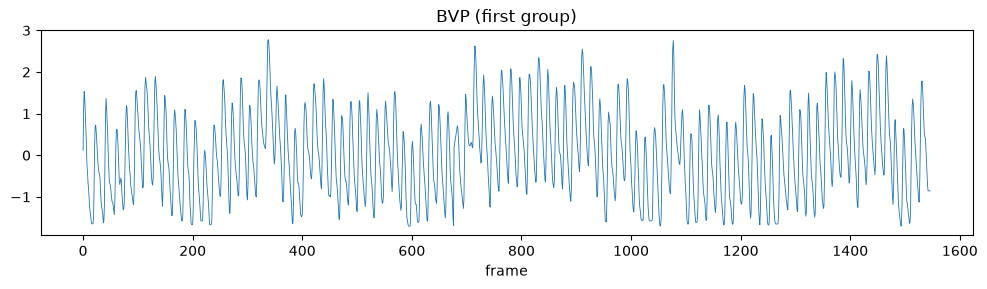

Usable: 42 / 42
Mean cardiac SQI: 0.381
Status counts: {'ok': np.int64(42)}

bvp_spectral_hr vs ref_hr (first 8):
source_file  bvp_spectral_hr     ref_hr
   subject1       106.690083 106.753174
  subject10       118.675334 109.843079
  subject11       121.961548  96.420143
  subject12        64.802311  65.937210
  subject13       109.831433 107.072464
  subject14        75.161658  80.340157
  subject15       112.502636 115.788750
  subject16        91.985642  91.803421


In [5]:
if OUT_H5.exists():
    with h5py.File(OUT_H5, 'r') as store:
        groups = sorted(store.keys())
        print('Groups in', OUT_H5.name, ':', len(groups))
        g0 = store[groups[0]]
        print('Example group:', groups[0])
        print('  datasets:', list(g0.keys()))
        print('  attrs:', dict(g0.attrs))
        if 'frames' in g0:
            fr = g0['frames']
            print('  frames:', fr.shape, fr.dtype, 'range', int(fr[0].min()), '-', int(fr[0].max()))
        bvp0 = g0['bvp'][:]
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(np.arange(len(bvp0)), bvp0, lw=0.6)
    ax.set_title('BVP (first group)')
    ax.set_xlabel('frame')
    plt.tight_layout()
    plt.show()

if len(log):
    print('Usable:', int(log['usable'].sum()), '/', len(log))
    print('Mean cardiac SQI:', round(float(log['cardiac_sqi'].mean()), 3))
    print('Status counts:', dict(log['status'].value_counts()))
    print()
    print('bvp_spectral_hr vs ref_hr (first 8):')
    print(log[['source_file', 'bvp_spectral_hr', 'ref_hr']].head(8).to_string(index=False))